In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("../data/processed/customers_clean.csv")
products = pd.read_csv("../data/processed/products_clean.csv")
sales = pd.read_csv("../data/processed/sales_clean.csv")

customer_segments = pd.read_csv(
    "../data/processed/customer_segments.csv"
)

In [3]:
print("Customers :", customers.shape)
print("Products :", products.shape)
print("Sales :", sales.shape)
print("Customer segments :", customer_segments.shape)

Customers : (7000, 7)
Products : (200, 5)
Sales : (30000, 7)
Customer segments : (7000, 2)


In [4]:
customer_segments.head()

,customer_id,segment
0,2001,0
1,2002,2
2,2003,2
3,2004,0
4,2005,2


fusion des résultats de M3 avec les infos clients

In [5]:
customer_data = customers.merge(
    customer_segments,
    on="customer_id",
    how="left"
)

In [6]:
customer_data.head()

,customer_id,name,age,gender,location,join_date,total_spent,segment
0,2001,Customer_2001,33,Female,New York,2021-12-13,0.00,0
1,2002,Customer_2002,59,Male,New York,2023-03-08,1103.79,2
2,2003,Customer_2003,51,Male,Houston,2021-04-29,1172.71,2
3,2004,Customer_2004,18,Male,Houston,2022-06-04,43.91,0
4,2005,Customer_2005,39,Female,Los Angeles,2023-01-03,1264.34,2


In [7]:
print("Nombre de clients :", len(customer_data))
print("Valeurs manquantes dans segment :")
print(customer_data["segment"].isnull().sum())

Nombre de clients : 7000
Valeurs manquantes dans segment :
0


In [8]:
#taille des segment

segment_counts = customer_data["segment"].value_counts().sort_index()

segment_counts

segment
0    2962
1    1008
2    3030
Name: count, dtype: int64

In [9]:
# Calcul du montant de chaque achat
sales["purchase_amount"] = (
    sales["quantity"] * sales["sale_price"]
)

# Calcul des indicateurs d'achat par client
customer_sales = sales.groupby("customer_id").agg(
    purchase_frequency=("sale_id", "count"),
    total_quantity=("quantity", "sum"),
    sales_amount=("purchase_amount", "sum"),
    average_basket=("purchase_amount", "mean")
).reset_index()

customer_sales.head()

,customer_id,purchase_frequency,total_quantity,sales_amount,average_basket
0,2002,5,9,1103.79,220.758000
1,2003,6,13,1172.71,195.451667
2,2004,1,1,43.91,43.910000
3,2005,7,16,1264.34,180.620000
4,2006,3,6,391.55,130.516667


In [10]:
customer_data = customer_data.merge(
    customer_sales,
    on="customer_id",
    how="left"
)

customer_data[
    [
        "purchase_frequency",
        "total_quantity",
        "sales_amount",
        "average_basket"
    ]
] = customer_data[
    [
        "purchase_frequency",
        "total_quantity",
        "sales_amount",
        "average_basket"
    ]
].fillna(0)

combien chaque client achète d'**Electronic Accessories.**

In [13]:
#calcul de l'affinité pour Electronic Accessories

sales_products = sales.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

electronic_purchases = (
    sales_products[
        sales_products["category"] == "Electronic Accessories"
    ]
    .groupby("customer_id")["quantity"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "quantity": "electronic_accessories_purchases"
        }
    )
)

customer_data = customer_data.merge(
    electronic_purchases,
    on="customer_id",
    how="left"
)

customer_data["electronic_accessories_purchases"] = (
    customer_data["electronic_accessories_purchases"].fillna(0)
)

In [12]:
#comparaison du segment 0 et 1

segment_summary = customer_data.groupby("segment").agg(
    customer_count=("customer_id", "count"),
    average_age=("age", "mean"),
    average_total_spent=("total_spent", "mean"),
    average_purchase_frequency=("purchase_frequency", "mean"),
    average_basket=("average_basket", "mean")
    # average_electronic_purchases=(
    #     "electronic_accessories_purchases",
    #     "mean"
    #)
).reset_index()

segment_summary

,segment,customer_count,average_age,average_total_spent,average_purchase_frequency,average_basket
0,0,2962,35.524646,166.305648,1.742404,74.783075
1,1,1008,35.326389,1881.721339,11.029762,175.046353
2,2,3030,35.576898,787.251241,4.528383,199.871597


première conclusion métier  
segment 0 : clients fidèles et à forte valeur  
segment 1 : clients occasionnels à faible engagement

Analysons avec le genre

In [13]:
gender_distribution = pd.crosstab(
    customer_data["segment"],
    customer_data["gender"],
    normalize="index"
) * 100

gender_distribution

gender,Female,Male
segment,,
0,53.173531,46.826469
1,50.496032,49.503968
2,52.574257,47.425743


le genre n'est pas très discriminant comme critère  


Analysons la localisation

In [14]:
location_distribution = pd.crosstab(
    customer_data["segment"],
    customer_data["location"],
    normalize="index"
) * 100

location_distribution.round(2)

location,Chicago,Houston,Los Angeles,New York,Phoenix
segment,,,,,
0,20.83,17.56,21.81,25.15,14.65
1,18.95,17.66,24.50,24.11,14.78
2,19.47,16.70,22.67,25.78,15.38


comme avec le genre, il n'y a pas beaucoup de différence 

L'analyse des catégories maintenant

In [16]:
sales_segments = (
    sales
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .merge(
        customer_data[["customer_id", "segment"]],
        on="customer_id",
        how="left"
    )
)

ccategory_quantity = (
    sales_segments
    .groupby(["segment", "category"])["quantity"]
    .sum()
    .reset_index()
)

dominant_category = (
    category_quantity
    .loc[
        category_quantity.groupby("segment")["quantity"].idxmax()
    ]
    .set_index("segment")["category"]
)

dominant_category

NameError: name 'category_quantity' is not defined

**Première recommandation:**  
Le segment 0 constitue la cible prioritaire pour les campagnes Electronic Accessories, car il combine une forte valeur client, une fréquence d'achat élevée et une affinité supérieure pour cette catégorie.  
pour le segment 1, Promotions ciblées, offres groupées, recommandations personnalisées ou campagnes de réactivation afin d'augmenter la fréquence d'achat et progressivement l'intérêt pour Electronic Accessories.

Maintenant il faut automatiser pour ne pas avoir à modifier manuellement le rapport avec d'autre données.

In [20]:
# Genre dominant par segment
dominant_gender = (
    customer_data.groupby("segment")["gender"]
    .agg(lambda x: x.value_counts().idxmax())
)

# Ville dominante par segment
dominant_location = (
    customer_data.groupby("segment")["location"]
    .agg(lambda x: x.value_counts().idxmax())
)

# Catégorie dominante par segment
dominant_category = (
    sales_segments.groupby("segment")["category"]
    .agg(lambda x: x.value_counts().idxmax())
)

dominant_gender, dominant_location, dominant_category

(segment
 0    Female
 1    Female
 Name: gender, dtype: object,
 segment
 0    New York
 1    New York
 Name: location, dtype: object,
 segment
 0         Home
 1    Lifestyle
 Name: category, dtype: object)

In [22]:
segment_profiles = segment_summary.copy()

segment_profiles["customer_percentage"] = (
    segment_profiles["customer_count"]
    / len(customer_data)
    * 100
)

segment_profiles["segment_name"] = segment_profiles["segment"].map({
    0: "Clients fidèles à forte valeur",
    1: "Clients occasionnels à faible engagement"
})

segment_profiles["dominant_gender"] = (
    dominant_gender.reindex(segment_profiles["segment"]).values
)

segment_profiles["dominant_location"] = (
    dominant_location.reindex(segment_profiles["segment"]).values
)

segment_profiles["dominant_category"] = (
    dominant_category.reindex(segment_profiles["segment"]).values
)



In [23]:
segment_profiles["electronic_affinity"] = np.where(
    segment_profiles["average_electronic_purchases"]
    >= segment_profiles["average_electronic_purchases"].mean(),
    "Forte",
    "Faible"
)

In [24]:
segment_profiles = segment_profiles[
    [
        "segment",
        "segment_name",
        "customer_count",
        "customer_percentage",
        "average_age",
        "average_total_spent",
        "average_purchase_frequency",
        "average_basket",
        "dominant_gender",
        "dominant_location",
        "dominant_category",
        "average_electronic_purchases",
        "electronic_affinity"
    ]
]

segment_profiles.round(2)

,segment,segment_name,customer_count,customer_percentage,average_age,average_total_spent,average_purchase_frequency,average_basket,dominant_gender,dominant_location,dominant_category,average_electronic_purchases,electronic_affinity
0,0,Clients fidèles à forte valeur,1820,26.0,35.35,1540.72,8.92,182.46,Female,New York,Home,3.29,Forte
1,1,Clients occasionnels à faible engagement,5180,74.0,35.58,380.43,2.66,129.63,Female,New York,Home,0.57,Faible


**Recommandation marketing par segment**

In [25]:
recommendations = pd.DataFrame({
    "segment": [0, 1],

    "target": [
        "Fidéliser et augmenter la valeur des clients",
        "Augmenter l'engagement et la fréquence d'achat"
    ],

    "marketing_strategy": [
        "Programme de fidélité, offres exclusives et ventes croisées",
        "Promotions ciblées, offres de découverte et relances personnalisées"
    ],

    "electronic_accessories_strategy": [
        "Proposer des accessoires complémentaires et des offres premium",
        "Utiliser des promotions attractives pour faire découvrir les accessoires électroniques"
    ],

    "recommended_action": [
        "Récompenser les clients fidèles et proposer des produits complémentaires",
        "Inciter les clients occasionnels à revenir et tester davantage de produits"
    ]
})

recommendations

,segment,target,marketing_strategy,electronic_accessories_strategy,recommended_action
0,0,Fidéliser et augmenter la valeur des clients,"Programme de fidélité, offres exclusives et ve...",Proposer des accessoires complémentaires et de...,Récompenser les clients fidèles et proposer de...
1,1,Augmenter l'engagement et la fréquence d'achat,"Promotions ciblées, offres de découverte et re...",Utiliser des promotions attractives pour faire...,Inciter les clients occasionnels à revenir et ...


**RECOMMANDATION SPECIFIQUE AUX "Electronic Accessories**  
puisque c'est le problème cantral du projet

In [26]:
electronic_recommendations = pd.DataFrame({
    "segment": [0, 1],

    "electronic_affinity": [
        "Forte",
        "Faible"
    ],

    "objective": [
        "Augmenter les ventes par client",
        "Développer l'intérêt pour la catégorie"
    ],

    "recommendation": [
        "Proposer des accessoires complémentaires et des offres personnalisées",
        "Proposer des promotions de découverte et des offres attractives"
    ]
})

electronic_recommendations

,segment,electronic_affinity,objective,recommendation
0,0,Forte,Augmenter les ventes par client,Proposer des accessoires complémentaires et de...
1,1,Faible,Développer l'intérêt pour la catégorie,Proposer des promotions de découverte et des o...


In [27]:
recommendations.to_csv(
    "../data/processed/segment_recommendations.csv",
    index=False
)

electronic_recommendations.to_csv(
    "../data/processed/electronic_recommendations.csv",
    index=False
)

print("Fichiers de recommandations créés avec succès.")

Fichiers de recommandations créés avec succès.


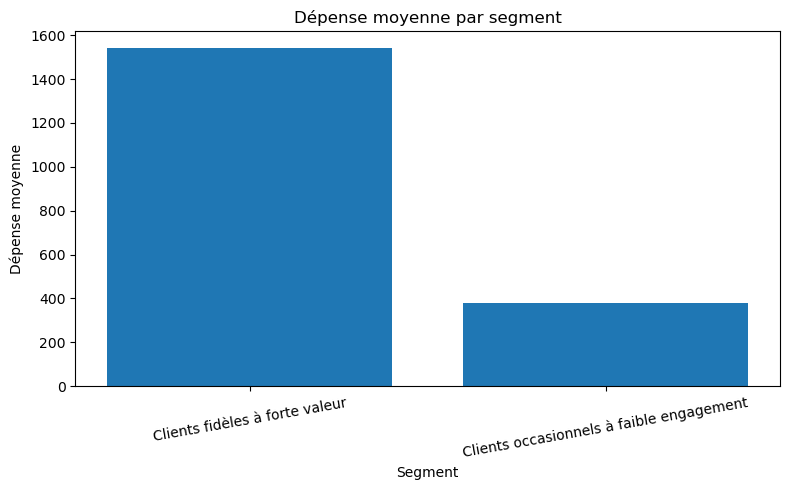

In [29]:
#la diff de valeur entre les segments 0 et 1 en graph simple

plt.figure(figsize=(8, 5))

plt.bar(
    segment_profiles["segment_name"],
    segment_profiles["average_total_spent"]
)

plt.title("Dépense moyenne par segment")
plt.xlabel("Segment")
plt.ylabel("Dépense moyenne")

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Conclusion du profilage

L'analyse des segments met en évidence deux profils de clients distincts.

Le segment 0 représente 26 % des clients et correspond à des clients fidèles à forte valeur. Ces clients présentent une fréquence d'achat, une dépense moyenne et un panier moyen supérieurs à ceux du segment 1. Leur consommation d'Electronic Accessories est également plus importante.

Le segment 1 représente 74 % des clients et correspond à des clients occasionnels à faible engagement. Ce segment constitue une opportunité importante de développement commercial, notamment en augmentant la fréquence d'achat et l'intérêt pour les Electronic Accessories.

Les différences de genre et de localisation étant relativement faibles entre les segments, les stratégies marketing doivent principalement être basées sur le comportement d'achat et la valeur client.

Ainsi, une stratégie différenciée est recommandée : fidéliser et développer la valeur des clients du segment 0, tandis que des promotions et campagnes de découverte peuvent être utilisées pour augmenter l'engagement du segment 1.